In [13]:
import numpy as np
import pandas as pd

from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

#from xgboost import XGBClassifier

In [14]:
SEASON_MAP = {
    12: "Winter",
    1: "Winter",
    2: "Winter",
    3: "Spring",
    4: "Spring",
    5: "Spring",
    6: "Summer",
    7: "Summer",
    8: "Summer",
    9: "Autumn",
    10: "Autumn",
    11: "Autumn",
}

TIME_BINS = [-1, 5, 9, 14, 19, 24]
TIME_LABELS = ["Night", "Morning_Rush", "Day", "Afternoon_Rush", "Evening"]

AGE_MAP = {
    "0 to 4": "Child",
    "5 to 9": "Child",
    "10 to 14": "Child",
    "15 to 19": "Young_Adult",
    "20 to 24": "Young_Adult",
    "25 to 29": "Adult",
    "30 to 34": "Adult",
    "35 to 39": "Adult",
    "40 to 44": "Adult",
    "45 to 49": "Adult",
    "50 to 54": "Adult",
    "55 to 59": "Adult",
    "60 to 64": "Adult",
    "65 to 69": "Senior",
    "70 to 74": "Senior",
    "75 to 79": "Senior",
    "80 to 84": "Senior",
    "85 to 89": "Senior",
    "90 to 94": "Senior",
    "Over 95": "Senior",
    "unknown": "Unknown",
    "Unknown": "Unknown",
}

PEDCOND_GROUPED_MAPPING = {
    "Unknown": "unknown",
    "Normal": "normal",
    "Inattentive": "inattentive",
    "Had Been Drinking": "substance_impaired",
    "Ability Impaired, Alcohol": "substance_impaired",
    "Ability Impaired, Drugs": "substance_impaired",
    "Ability Impaired, Alcohol Over .80": "substance_impaired",
    "Medical or Physical Disability": "medical_issue",
    "Fatigue": "medical_issue",
    "Other": "other",
}

DRIVCOND_GROUPED_MAPPING = {
    "Unknown": "unknown",
    "Normal": "normal",
    "Inattentive": "inattentive",
    "Had Been Drinking": "substance_impaired",
    "Ability Impaired, Alcohol": "substance_impaired",
    "Ability Impaired, Alcohol Over .08": "substance_impaired",
    "Ability Impaired, Drugs": "substance_impaired",
    "Medical or Physical Disability": "medical_issue",
    "Fatigue": "medical_issue",
    "Other": "other",
}

PEDACT_GROUPED_MAPPING = {
    "Unknown": "unknown",
    "Crossing with right of way": "crossing",
    "Crossing, no Traffic Control": "crossing",
    "Crossing without right of way": "crossing",
    "Crossing, Pedestrian Crossover": "crossing",
    "Crossing marked crosswalk without ROW": "crossing",
    "Walking on Roadway with Traffic": "walking_roadway",
    "Walking on Roadway Against Traffic": "walking_roadway",
    "Running onto Roadway": "sudden_entry",
    "Coming From Behind Parked Vehicle": "sudden_entry",
    "On Sidewalk or Shoulder": "sidewalk_shoulder",
    "Person Getting on/off Vehicle": "vehicle_related",
    "Person Getting on/off School Bus": "vehicle_related",
    "Pushing/Working on Vehicle": "vehicle_related",
    "Playing or Working on Highway": "other",
    "Other": "other",
}

PEDESTRIAN_GROUPED_MAPPING = {
    "Pedestrian hit at mid-block": "mid_block",
    "Vehicle hits the pedestrian walking or running out from between parked vehicles at mid-block": "mid_block",
    "Pedestrian hit a PXO/ped. Mid-block signal": "mid_block",
    "Vehicle turns left while ped crosses with ROW at inter.": "intersection_turning",
    "Vehicle turns left while ped crosses without ROW at inter.": "intersection_turning",
    "Vehicle turns right while ped crosses with ROW at inter.": "intersection_turning",
    "Vehicle turns right while ped crosses without ROW at inter.": "intersection_turning",
    "Vehicle is going straight thru inter.while ped cross with ROW": "intersection_straight",
    "Vehicle is going straight thru inter.while ped cross without ROW": "intersection_straight",
    "Pedestrian hit on sidewalk or shoulder": "sidewalk_shoulder",
    "Pedestrian hit at private driveway": "private_property",
    "Pedestrian hit at parking lot": "private_property",
    "Vehicle is reversing and hits pedestrian": "reversing",
    "Pedestrian involved in a collision with transit vehicle anywhere along roadway": "transit_collision",
    "Unknown": "unknown",
    "Other / Undefined": "other",
}

CYCLISTYPE_GROUPED_MAPPING = {
    "Unknown": "unknown",
    "Insufficient information (to determine cyclist crash type).": "unknown",
    "Motorist turned left across cyclists path.": "motorist_turn_conflict",
    "Motorist turns right at non-signal Inter.(stop, yield, no cont.,and dwy) and strikes cyclist.": "motorist_turn_conflict",
    "Motorist turning right on green or amber at signalized intersection strikes cyclist.": "motorist_turn_conflict",
    "Motorist turning right on red at signalized intersection strikes cyclist.": "motorist_turn_conflict",
    "Motorist makes u-turn in-front of cyclist.": "motorist_turn_conflict",
    "Cyclist turned left across motorists path.": "cyclist_turn_conflict",
    "Cyclist turns right across motorists path": "cyclist_turn_conflict",
    "Cyclist makes u-turn in-front of driver.": "cyclist_turn_conflict",
    "Cyclist without ROW rides into path of motorist at inter, lnwy, dwy-Cyclist not turn.": "row_violation",
    "Motorist without ROW drives into path of cyclist at inter, lnwy, dwy-Driver not turn.": "row_violation",
    "Cyclist and Driver travelling in same direction. One vehicle sideswipes the other.": "same_direction_collision",
    "Cyclist and Driver travelling in same direction. One vehicle rear-ended the other.": "same_direction_collision",
    "Cyclist struck opened vehicle door": "dooring",
    "Cyclist loses control and strikes object (pole, ttc track)": "cyclist_loss_control",
    "Cyclist falls off bike - no contact with motorist.": "cyclist_loss_control",
    "Cyclist strikes a parked vehicle.": "cyclist_loss_control",
    "Cyclist rode off sidewalk into road at midblock.": "midblock_entry",
    "Motorist reversing struck cyclist.": "reversing_collision",
    "Motorist loses control and strikes cyclist.": "reversing_collision",
    "Cyclist strikes pedestrian.": "pedestrian_conflict",
    "Cyclist struck at PXO(cyclist either travel in same dir. as veh. or ride across xwalk)": "crossing_facility",
}

ROW_DROP_COLUMNS = [
    "OBJECTID",
    "INDEX",
    "STREET1",
    "STREET2",
    "OFFSET",
    "LATITUDE",
    "LONGITUDE",
    "INJURY",
    "FATAL_NO",
    "VEHTYPE",
    "HOOD_158",
    "HOOD_140",
    "NEIGHBOURHOOD_140",
    "DIVISION",
    "x",
    "y",
    "NEIGHBOURHOOD_158",
]

GROUPED_COLUMNS_TO_DROP = ["PEDCOND", "DRIVCOND", "PEDACT", "PEDTYPE", "CYCLISTYPE"]

In [15]:
def _build_accident_split(data, test_size=0.2, random_state=42):
    accident_labels = (
        data.assign(FATAL_ACCIDENT=(data["ACCLASS"] == "Fatal").astype(int))
        .groupby("ACCNUM", as_index=False)["FATAL_ACCIDENT"]
        .max()
    )
    train_ids, test_ids = train_test_split(
        accident_labels["ACCNUM"],
        test_size=test_size,
        random_state=random_state,
        stratify=accident_labels["FATAL_ACCIDENT"],
    )
    return set(train_ids), set(test_ids)


def _fill_missing_values(X_train, X_test):
    fill_values = {}
    for column in X_train.columns:
        if not X_train[column].isnull().any():
            continue
        if pd.api.types.is_numeric_dtype(X_train[column]):
            fill_values[column] = X_train[column].median()
        else:
            unique_values = set(X_train[column].dropna().astype(str).unique())
            fill_values[column] = "No" if "Yes" in unique_values else "Unknown"
    X_train = X_train.fillna(fill_values)
    X_test = X_test.fillna(fill_values)
    return X_train, X_test


def _add_time_features(frame):
    frame = frame.copy()
    frame["DATE"] = pd.to_datetime(frame["DATE"])
    frame["TIME"] = pd.to_numeric(frame["TIME"], errors="coerce").fillna(0)
    frame["HOUR"] = frame["TIME"] // 100
    frame["SEASON"] = frame["DATE"].dt.month.map(SEASON_MAP)
    frame["IS_WEEKEND"] = frame["DATE"].dt.dayofweek.apply(lambda value: 1 if value >= 5 else 0)
    frame["TIME_RANGE"] = pd.cut(frame["HOUR"], bins=TIME_BINS, labels=TIME_LABELS)
    frame["AGE_GROUP"] = frame["INVAGE"].map(AGE_MAP).fillna("Unknown")
    return frame


def _add_grouped_columns(frame):
    frame = frame.copy()
    frame["PEDCOND_GRP"] = frame["PEDCOND"].map(PEDCOND_GROUPED_MAPPING).fillna("other")
    frame["DRIVCOND_GRP"] = frame["DRIVCOND"].map(DRIVCOND_GROUPED_MAPPING).fillna("other")
    frame["PEDACT_GRP"] = frame["PEDACT"].map(PEDACT_GROUPED_MAPPING).fillna("other")
    frame["PEDTYPE_GRP"] = frame["PEDTYPE"].map(PEDESTRIAN_GROUPED_MAPPING).fillna("other")
    frame["CYCLISTYPE_GRP"] = frame["CYCLISTYPE"].map(CYCLISTYPE_GROUPED_MAPPING).fillna("other")
    return frame


def _preprocess_rows(X_train, X_test):
    X_train = X_train.fillna('Unknown')
    X_test = X_test.fillna('Unknown')

    for frame in [X_train, X_test]:
        cat_cols = frame.select_dtypes(include=['object']).columns
        for col in cat_cols:
            frame[col] = frame[col].astype(str).str.strip()

    X_train = _add_time_features(X_train)
    X_test = _add_time_features(X_test)
    
    for frame in [X_train, X_test]:
        frame['hour_sin'] = np.sin(2 * np.pi * frame['HOUR'] / 24.0)
        frame['hour_cos'] = np.cos(2 * np.pi * frame['HOUR'] / 24.0)

    X_train = _add_grouped_columns(X_train)
    X_test = _add_grouped_columns(X_test)

    # Удаляем старые колонки времени и возраста
    cols_to_drop = ["DATE", "TIME", "HOUR", "INVAGE"] + GROUPED_COLUMNS_TO_DROP
    X_train = X_train.drop(columns=cols_to_drop)
    X_test = X_test.drop(columns=cols_to_drop)

    X_train_final = pd.get_dummies(X_train, drop_first=True)
    X_test_final = pd.get_dummies(X_test, drop_first=True)

    cols_to_remove = [c for c in X_train_final.columns if '_Unknown' in c or '_nan' in c or '_unknown' in c]
    X_train_final.drop(columns=cols_to_remove, inplace=True, errors='ignore')
    X_test_final.drop(columns=cols_to_remove, inplace=True, errors='ignore')

    X_train_final, X_test_final = X_train_final.align(X_test_final, join="left", axis=1, fill_value=0)
    return X_train_final.fillna(0), X_test_final.fillna(0)


def _aggregate_accident_features(X_encoded, accident_ids):
    temp_df = X_encoded.copy()
    temp_df["ACCNUM"] = accident_ids.values
    
    all_cols = [c for c in X_encoded.columns if c != "ACCNUM"]
    
    columns_to_sum = [col for col in all_cols if any(prefix in col for prefix in 
                     ['INVTYPE_', 'DRIVACT_', 'CYCACT_', 'PEDACT_', 'DRIVCOND_', 'PEDCOND_', 
                      'MANOEUVER_', 'IMPACTYPE_', 'CYCCOND_'])]
    
    columns_to_max = [col for col in all_cols if col not in columns_to_sum]
    
    agg_funcs = {col: 'sum' for col in columns_to_sum}
    agg_funcs.update({col: 'max' for col in columns_to_max})
    
    accident_features = temp_df.groupby("ACCNUM").agg(agg_funcs)
    
    participant_count = accident_ids.value_counts().rename("PARTICIPANT_COUNT")
    accident_features["PARTICIPANT_COUNT"] = participant_count.reindex(accident_features.index).fillna(0)
    
    return accident_features.sort_index()



def _aggregate_accident_target(y_rows, accident_ids):
    accident_target = (
        pd.DataFrame({"ACCNUM": accident_ids.values, "FATAL_ACCIDENT": (y_rows == "Fatal").astype(int).values})
        .groupby("ACCNUM", as_index=True)["FATAL_ACCIDENT"]
        .max()
        .sort_index()
    )
    return accident_target


def prepare_accident_level_data(csv_path="TOTAL_KSI_3737821728629277523.csv", test_size=0.2, random_state=42):
    data = pd.read_csv(csv_path)
    data = data[data["ACCNUM"].notna() & data["ACCLASS"].notna()].copy()

    train_accidents, test_accidents = _build_accident_split(
        data,
        test_size=test_size,
        random_state=random_state,
    )

    train_rows = data[data["ACCNUM"].isin(train_accidents)].copy()
    test_rows = data[data["ACCNUM"].isin(test_accidents)].copy()

    train_accnum = train_rows["ACCNUM"].copy()
    test_accnum = test_rows["ACCNUM"].copy()

    data_new_train = train_rows.drop(columns=ROW_DROP_COLUMNS)
    data_new_test = test_rows.drop(columns=ROW_DROP_COLUMNS)

    X_train_rows = data_new_train.drop(columns=["ACCLASS", "ACCNUM"])
    X_test_rows = data_new_test.drop(columns=["ACCLASS", "ACCNUM"])
    y_train_rows = train_rows["ACCLASS"]
    y_test_rows = test_rows["ACCLASS"]

    X_train_final, X_test_final = _preprocess_rows(X_train_rows, X_test_rows)

    X_train_accident = _aggregate_accident_features(X_train_final, train_accnum)
    X_test_accident = _aggregate_accident_features(X_test_final, test_accnum)
    y_train_accident = _aggregate_accident_target(y_train_rows, train_accnum)
    y_test_accident = _aggregate_accident_target(y_test_rows, test_accnum)

    X_train_accident, X_test_accident = X_train_accident.align(
        X_test_accident,
        join="left",
        axis=1,
        fill_value=0,
    )
    y_test_accident = y_test_accident.reindex(X_test_accident.index)
    y_train_accident = y_train_accident.reindex(X_train_accident.index)

    scaler = StandardScaler()

    X_train_acc_scaled = scaler.fit_transform(X_train_accident)
    X_test_acc_scaled = scaler.transform(X_test_accident)

    # Чтобы сохранить имена колонок (StandardScaler возвращает numpy array), 
    # можно обернуть обратно в DataFrame, если хочешь видеть графики потом
    X_train_final = pd.DataFrame(X_train_acc_scaled, columns=X_train_accident.columns, index=X_train_accident.index)
    X_test_final = pd.DataFrame(X_test_acc_scaled, columns=X_test_accident.columns, index=X_test_accident.index)

    return X_train_final, X_test_final, y_train_accident.astype(int), y_test_accident.astype(int)

if __name__ == "__main__":
    X_train_acc, X_test_acc, y_train_acc, y_test_acc = prepare_accident_level_data()
    
    for df in [X_train_acc, X_test_acc]:
        df['VULNERABILITY_SENIOR_PED'] = df['AGE_GROUP_Senior'] * df['PEDESTRIAN_Yes']
        df['BLIND_SPOT_CRASH'] = df['PEDTYPE_GRP_private_property'] * df['MANOEUVER_Overtaking']
        df['TRUCK_EXCEEDS_LIMIT'] = df['DRIVACT_Exceeding Speed Limit'] * df['INVTYPE_Truck Driver']
        df['FATAL_COMBO_RAIN_SPEED'] = df['VISIBILITY_Rain'] * df['DRIVACT_Speed too Fast For Condition']
    
    
    X_train_final = X_train_acc.astype("float32")
    y_train_final = y_train_acc.astype("float32")
    X_test_final = X_test_acc.astype("float32")
    y_test_final = y_test_acc.astype("float32")

    print(X_train_final.shape[0])


/var/folders/p5/rcdm79k905n5dywxsh_rw8nw0000gn/T/ipykernel_23479/2835003116.py:58: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = frame.select_dtypes(include=['object']).columns
/var/folders/p5/rcdm79k905n5dywxsh_rw8nw0000gn/T/ipykernel_23479/2835003116.py:58: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https:

3963


In [16]:
X_test_final.shape

(991, 182)

In [17]:
X_train_final.shape

(3963, 182)

In [18]:
y_test_final.value_counts()

FATAL_ACCIDENT
0.0    866
1.0    125
Name: count, dtype: int64

In [19]:
y_train_final.value_counts()

FATAL_ACCIDENT
0.0    3465
1.0     498
Name: count, dtype: int64

In [20]:
y_train_final.value_counts()/sum(y_train_final.value_counts())

FATAL_ACCIDENT
0.0    0.874338
1.0    0.125662
Name: count, dtype: float64

In [22]:
# ============================================================
# Random Forest vs Gradient Boosting
# Hyperparameter tuning with CV on F1 score
# Compare on Test Set:
# AUC, F1, Precision, Recall
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

# ============================================================
# ASSUMPTION:
# You already have:
# X_train, X_test, y_train, y_test
# Binary classification target
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ============================================================
# 1. Random Forest
# ============================================================

rf_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=rf_params,
    n_iter=20,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_search.fit(X_train_final, y_train_final)

# ============================================================
# 2. Gradient Boosting
# ============================================================

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_params = {
    "n_estimators": [100, 200, 300,500],
    "learning_rate": [0.001, 0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4,5,6,10,20,50],
    "min_samples_split": [2, 5, 10,12,15],
    "subsample": [0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    estimator=gb_model,
    param_distributions=gb_params,
    n_iter=20,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

gb_search.fit(X_train_final, y_train_final)

# ============================================================
# Evaluation Function
# ============================================================

def evaluate_model(model, X_test, y_test, name):
    
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    
    results = {
        "Model": name,
        "AUC": roc_auc_score(y_test, prob),
        "F1": f1_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred)
    }
    
    return results

# ============================================================
# Compare Best Models
# ============================================================

results = []

results.append(
    evaluate_model(
        rf_search.best_estimator_,
        X_test_final,
        y_test_final,
        "RandomForest"
    )
)

results.append(
    evaluate_model(
        gb_search.best_estimator_,
        X_test_final,
        y_test_final,
        "GradientBoosting"
    )
)

results_df = pd.DataFrame(results).sort_values(
    by="F1",
    ascending=False
)

print(results_df)

# ============================================================
# Best Params
# ============================================================

print("\nBest Random Forest Params:")
print(rf_search.best_params_)

print("\nBest Gradient Boosting Params:")
print(gb_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
              Model       AUC       F1  Precision  Recall
1  GradientBoosting  0.704240  0.20765   0.327586   0.152
0      RandomForest  0.703455  0.00000   0.000000   0.000

Best Random Forest Params:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Best Gradient Boosting Params:
{'subsample': 1.0, 'n_estimators': 500, 'min_samples_split': 15, 'max_depth': 6, 'learning_rate': 0.1}


/Users/ajithpunnen/opt/anaconda3/envs/mluoft/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [23]:
best_gb = gb_search.best_estimator_

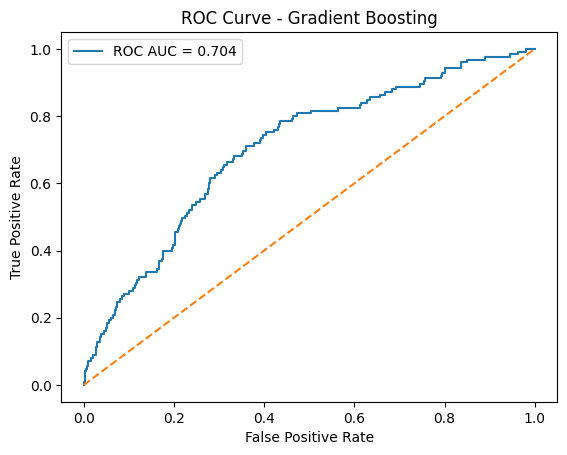

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# probabilities
y_prob = best_gb.predict_proba(X_test_final)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test_final, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()
plt.show()

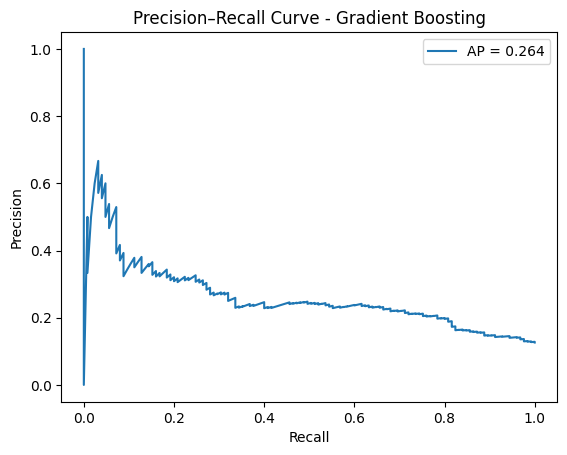

In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test_final, y_prob)
ap_score = average_precision_score(y_test_final, y_prob)

plt.figure()
plt.plot(recall, precision, label=f"AP = {ap_score:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve - Gradient Boosting")
plt.legend()
plt.show()

In [26]:
feature_importance = pd.DataFrame({
    "feature": X_train_final.columns,
    "importance": best_gb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance.head(20))

                             feature  importance
85                          hour_sin    0.056625
86                          hour_cos    0.050303
180              TRUCK_EXCEEDS_LIMIT    0.038387
178         VULNERABILITY_SENIOR_PED    0.034620
76               DRIVCOND_GRP_normal    0.034573
177                PARTICIPANT_COUNT    0.025388
72                PEDCOND_GRP_normal    0.024703
28             MANOEUVER_Going Ahead    0.023949
3    IMPACTYPE_Pedestrian Collisions    0.022459
5                IMPACTYPE_SMV Other    0.022216
24             INVTYPE_Vehicle Owner    0.014171
95               DISTRICT_North York    0.013790
97    DISTRICT_Toronto and East York    0.013568
137                     INITDIR_West    0.013532
19                 INVTYPE_Passenger    0.013482
48              DRIVACT_Lost control    0.012901
152                    SEASON_Summer    0.012756
49                     DRIVACT_Other    0.011723
111          TRAFFCTL_Traffic Signal    0.011347
100          ACCLOC_

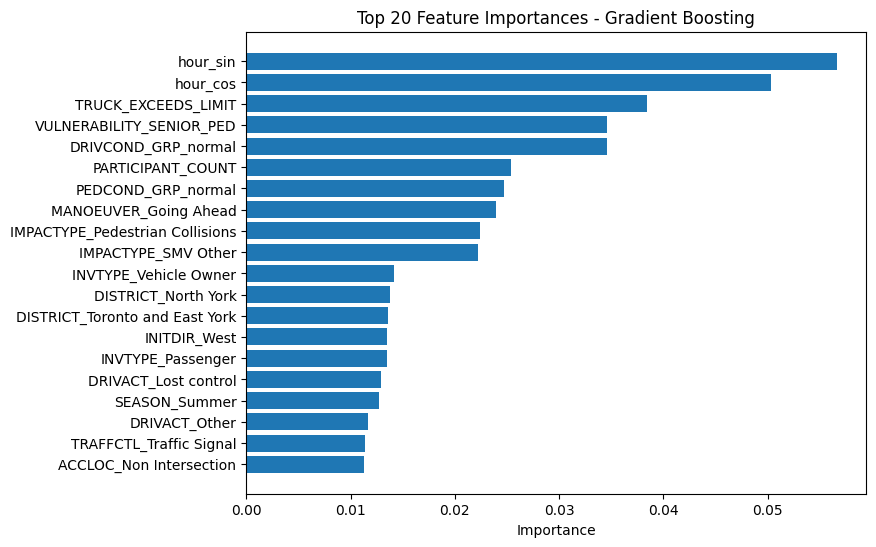

In [27]:
top_features = feature_importance.head(20)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"][::-1], top_features["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances - Gradient Boosting")
plt.show()

In [28]:
import pandas as pd
import numpy as np
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# Best model from your tuning
#model = gb_search.best_estimator_

# Compute permutation importance
result = permutation_importance(
    best_gb,
    X_test_final,
    y_test_final,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

# Create dataframe
perm_importance = pd.DataFrame({
    "feature": X_test_final.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
})

# Sort
perm_importance = perm_importance.sort_values(
    by="importance_mean",
    ascending=False
)

# Top 20
top20 = perm_importance.head(20)

print(top20)

                            feature  importance_mean  importance_std
178        VULNERABILITY_SENIOR_PED         0.017071        0.013637
17                    INVTYPE_Other         0.016871        0.006839
139                     CYCLIST_Yes         0.015693        0.009259
142                       TRUCK_Yes         0.015151        0.006652
107              TRAFFCTL_Stop Sign         0.013512        0.004634
48             DRIVACT_Lost control         0.012475        0.011376
76              DRIVCOND_GRP_normal         0.012439        0.012825
97   DISTRICT_Toronto and East York         0.011094        0.014468
42    DRIVACT_Exceeding Speed Limit         0.009501        0.003510
1      IMPACTYPE_Cyclist Collisions         0.009296        0.003140
122          LIGHT_Dawn, artificial         0.008863        0.002954
33                 MANOEUVER_Parked         0.008308        0.004237
140                  AUTOMOBILE_Yes         0.006591        0.007282
147                     AG_DRIV_Ye

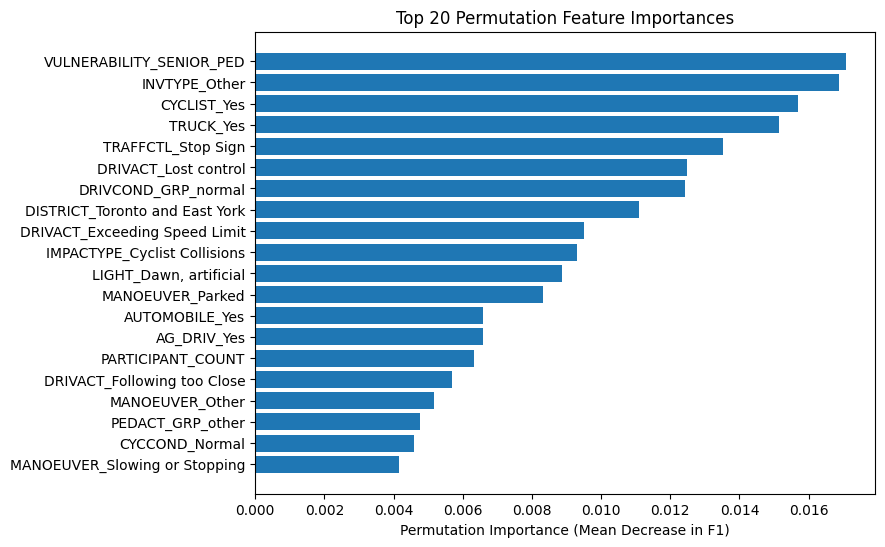

In [29]:
plt.figure(figsize=(8, 6))

plt.barh(
    top20["feature"][::-1],
    top20["importance_mean"][::-1]
)

plt.xlabel("Permutation Importance (Mean Decrease in F1)")
plt.title("Top 20 Permutation Feature Importances")
plt.show()

In [30]:
import shap

explainer = shap.TreeExplainer(best_gb)
shap_values = explainer.shap_values(X_test_final)

/Users/ajithpunnen/opt/anaconda3/envs/mluoft/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


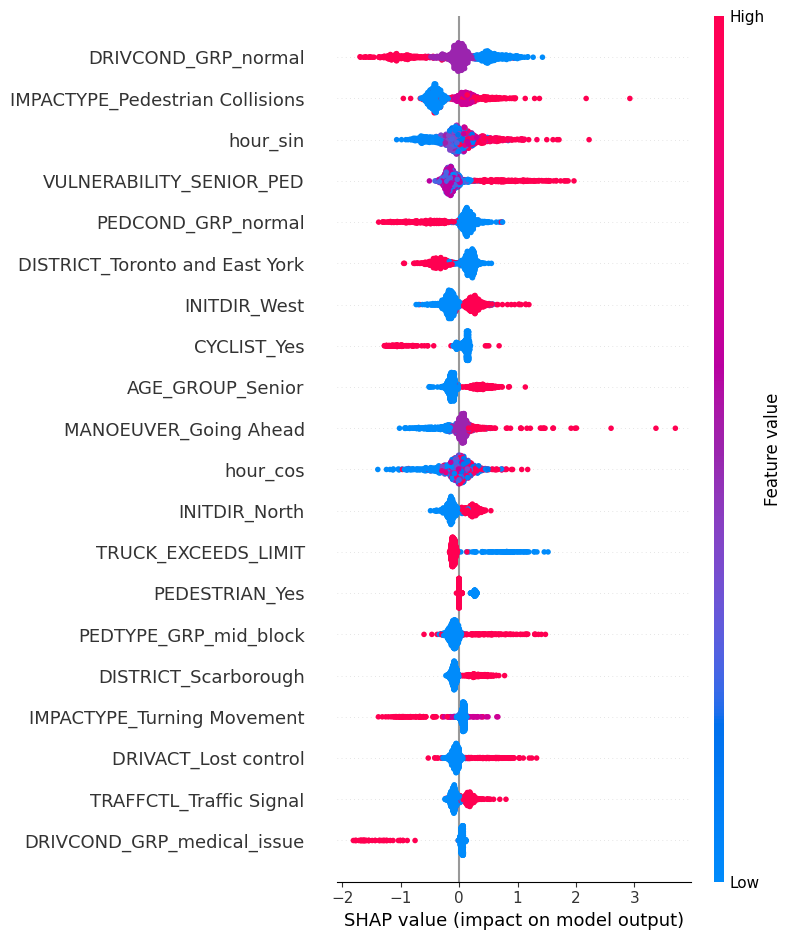

In [31]:
shap.summary_plot(shap_values, X_test_final, feature_names=X_train_final.columns)

In [32]:
explainer = shap.TreeExplainer(best_gb)

shap_values = explainer(X_test_final)

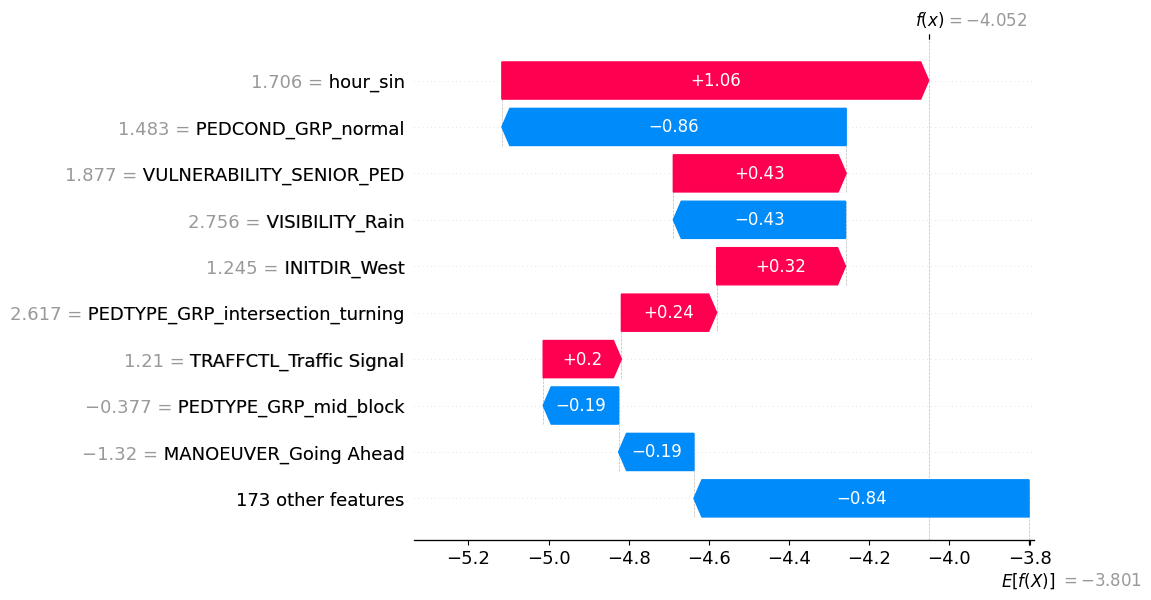

In [33]:
i = 2  # choose row index

shap.plots.waterfall(shap_values[i])